# Préparation des données Parcoursup

Ce bloc prépare une base propre avant l'analyse uni-dimensionnelle :
- chargement des données,
- sélection des variables utiles,
- création d'indicateurs simples et interprétables pour l'analyse.


In [60]:
library(tidyverse)

# lecture du CSV Parcoursup (sep=';' car format français, check.names pour noms exploitables en R)
data <- read.csv('Parcoursup.csv', sep = ';', header = TRUE, stringsAsFactors = TRUE, check.names = TRUE)

# Contrôle minimal : nombre de lignes/colonnes + aperçu de 3 lignes
dim(data)
head(data, 3)


[1] 14252   118

,Session,Statut.de.l.établissement.de.la.filière.de.formation..public..privé..,Code.UAI.de.l.établissement,Établissement,Code.départemental.de.l.établissement,Département.de.l.établissement,Région.de.l.établissement,Académie.de.l.établissement,Commune.de.l.établissement,Filière.de.formation,⋯,tri,cod_aff_form,Concours.communs.et.banque.d.épreuves,Lien.de.la.formation.sur.la.plateforme.Parcoursup,Taux.d.accès,Part.des.terminales.générales.qui.étaient.en.position.de.recevoir.une.proposition.en.phase.principale,Part.des.terminales.technologiques.qui.étaient.en.position.de.recevoir.une.proposition.en.phase.principale,Part.des.terminales.professionnelles.qui.étaient.en.position.de.recevoir.une.proposition.en.phase.principale,etablissement_id_paysage,composante_id_paysage
,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,⋯,<fct>,<int>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<lgl>,<lgl>
1,2025,Public,0692185A,INSTITUT DES SCIENCES ET TECHNIQUES DE LA READAPTATION UNIVERSITE LYON 1,69,Rhône,Auvergne-Rhône-Alpes,Lyon,Lyon 8e Arrondissement,Certificat de capacité d'Orthoptiste,⋯,3_Autres formations,28087,Aix-Marseille Université - Site de Marseille Timone,https://dossierappel.parcoursup.fr/Candidats/public/fiches/afficherFicheFormation?g_ta_cod=28087&typeBac=0&originePc=0,13,93,7,1,NA,NA
2,2025,Public,0931827F,Université Paris 8,93,Seine-Saint-Denis,Ile-de-France,Créteil,Saint-Denis,Licence - Langues étrangères appliquées - Parcours Anglais / Italien,⋯,1_universités,28100,,https://dossierappel.parcoursup.fr/Candidats/public/fiches/afficherFicheFormation?g_ta_cod=28100&typeBac=0&originePc=0,98,57,24,19,NA,NA
3,2025,Public,0421573G,IFSI du CH de Roanne,42,Loire,Auvergne-Rhône-Alpes,Lyon,Roanne,D.E Infirmier,⋯,3_Autres formations,28144,,https://dossierappel.parcoursup.fr/Candidats/public/fiches/afficherFicheFormation?g_ta_cod=28144&typeBac=0&originePc=0,40,56,37,7,NA,NA


## Vérification rapide

On vérifie la structure globale sans multiplier les diagnostics : dimensions, types et quelques statistiques de base.


In [61]:
# Vue d'ensemble des types de variables (numériques, caractères, etc.)
glimpse(data)

# Résumé ciblé sur des variables de volume utiles pour la suite
summary(select(data,
  Capacité.de.l.établissement.par.formation,
  Effectif.total.des.candidats.pour.une.formation,
  Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.
))


Rows: 14,252
Columns: 118
$ Session                                                                                                                                          <int> …
$ Statut.de.l.établissement.de.la.filière.de.formation..public..privé..                                                                            <fct> …
$ Code.UAI.de.l.établissement                                                                                                                      <fct> …
$ Établissement                                                                                                                                    <fct> …
$ Code.départemental.de.l.établissement                                                                                                            <fct> …
$ Département.de.l.établissement                                                                                                                   <fct> …
$ Région.de.l.établissement                 

 Capacité.de.l.établissement.par.formation
 Min.   :   0.00                          
 1st Qu.:  18.00                          
 Median :  30.00                          
 Mean   :  53.98                          
 3rd Qu.:  50.00                          
 Max.   :3400.00                          
 Effectif.total.des.candidats.pour.une.formation
 Min.   :    1.0                                
 1st Qu.:  160.0                                
 Median :  385.0                                
 Mean   :  947.4                                
 3rd Qu.: 1016.0                                
 Max.   :19404.0                                
 Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.
 Min.   :   0.00                                                                     
 1st Qu.:  14.00                                                                     
 Median :  25.00                                                                     
 Mean   :  4

## Nettoyage et variables construites

Logique du nettoyage :
- retirer les colonnes techniques ou trop fines pour l'objectif (identifiants, GPS, liens, détails redondants),
- conserver les colonnes utiles à l'analyse genre/sélectivité/profil des admis,
- construire des variables agrégées simples (2 phases, pourcentages de genre, parts de mentions).


In [62]:
# Colonnes retirées : identifiants techniques, géographie trop fine, détails redondants
cols_to_drop <- c(
  'Session',
  'Code.UAI.de.l.établissement',
  'Code.départemental.de.l.établissement',
  'Département.de.l.établissement',
  'Coordonnées.GPS.de.la.formation',
  'Commune.de.l.établissement',
  'Filière.de.formation.détaillée',
  'Filière.de.formation.détaillée.bis',
  'Filière.de.formation.très.détaillée',
  'Dont.effectif.des.candidats.ayant.postulé.en.internat',
  'Effectif.total.des.candidats.classés.par.l.établissement.en.phase.principale',
  'Effectif.des.candidats.classés.par.l.établissement.en.phase.complémentaire',
  'Effectif.des.candidats.classés.par.l.établissement.en.internat..CPGE.',
  'Effectif.des.candidats.classés.par.l.établissement.hors.internat..CPGE.',
  'Concours.communs.et.banque.d.épreuves',
  'cod_aff_form',
  'Lien.de.la.formation.sur.la.plateforme.Parcoursup',
  'etablissement_id_paysage',
  'composante_id_paysage'
)

# any_of : évite une erreur si une colonne listée est absente
data <- data %>%
  select(-any_of(cols_to_drop))

# Colonnes converties en numérique avant calcul de ratios
num_cols <- c(
  'Capacité.de.l.établissement.par.formation',
  'Effectif.total.des.candidats.en.phase.principale',
  'Effectif.total.des.candidats.en.phase.complémentaire',
  'Effectif.des.admis.en.phase.principale',
  'Effectif.des.admis.en.phase.complémentaire',
  'Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.',
  'Dont.effectif.des.candidates.admises',
  'Effectif.des.admis.néo.bacheliers',
  'Dont.effectif.des.admis.néo.bacheliers.sans.mention.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Assez.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.au.bac',
  'Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.avec.félicitations.au.bac'
)

data <- data %>%
  # across(...): applique as.numeric à toutes les colonnes de num_cols
  mutate(across(any_of(num_cols), ~ suppressWarnings(as.numeric(.x)))) %>%
  mutate(
    # Agrégation des volumes sur les deux phases d'admission
    Effectif.total.candidats.2phases = coalesce(Effectif.total.des.candidats.en.phase.principale, 0) +
      coalesce(Effectif.total.des.candidats.en.phase.complémentaire, 0),
    Effectif.total.admis.2phases = coalesce(Effectif.des.admis.en.phase.principale, 0) +
      coalesce(Effectif.des.admis.en.phase.complémentaire, 0),
      #coalesce remplace les valeurs manquantes par 0

    # Parts filles/garçons parmi les admis (entre 0 et 1)
    pct_filles_admises = if_else(
      Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis. > 0,
      Dont.effectif.des.candidates.admises / Effectif.total.des.candidats.ayant.accepté.la.proposition.de.l.établissement..admis.,
      NA_real_
    ),
    pct_garcons_admis = if_else(!is.na(pct_filles_admises), 1 - pct_filles_admises, NA_real_),

    # Parts de mentions parmi les admis néo-bacheliers
    part_mention_ab = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Assez.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_b = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_tb = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_),
    part_mention_tb_fel = if_else(Effectif.des.admis.néo.bacheliers > 0,
      Dont.effectif.des.admis.néo.bacheliers.avec.mention.Très.Bien.avec.félicitations.au.bac / Effectif.des.admis.néo.bacheliers, NA_real_)
  )


## Features principales pour l'analyse

On crée un jeu de features simple et cohérent avec le cours : ratios interprétables, transformations log des volumes et discrétisation par quantiles.


In [63]:
data <- data %>%
  rename(Statut.Etablissement = "Statut.de.l.établissement.de.la.filière.de.formation..public..privé..") 

data <- data %>%
  mutate(Statut.Etablissement = case_when(
    grepl("^Public", Statut.Etablissement) ~ "Public",
    grepl("^Privé",  Statut.Etablissement) ~ "Privé",
    TRUE ~ Statut.Etablissement  # garder les autres valeurs
  ))

data$Statut.Etablissement <- as.factor(data$Statut.Etablissement)

In [64]:
data <- data %>%
  mutate(
    # Total candidats et boursiers candidats (tous bacs confondus)
    total_candidats = Effectif.des.candidats.néo.bacheliers.généraux.en.phase.principale +
                      Effectif.des.candidats.néo.bacheliers.technologiques.en.phase.principale +
                      Effectif.des.candidats.néo.bacheliers.professionnels.en.phase.principale,
    
    total_boursiers_candidats = Dont.effectif.des.candidats.boursiers.néo.bacheliers.généraux.en.phase.principale +
                                Dont.effectif.des.candidats.boursiers.néo.bacheliers.technologiques.en.phase.principale +
                                Dont.effectif.des.candidats.boursiers.néo.bacheliers.professionnels.en.phase.principale,
    
    # Nouvelles features
    Pourcentage.boursiers.candidats = (total_boursiers_candidats / total_candidats) * 100,
    Pourcentage.boursiers.admis     = (Dont.effectif.des.admis.boursiers.néo.bacheliers / 
                                       Effectif.des.admis.néo.bacheliers) * 100
  ) %>%
  # Supprimer les colonnes intermédiaires
  select(-total_candidats, -total_boursiers_candidats)

In [65]:
glimpse(data)

Rows: 14,252
Columns: 109
$ Statut.Etablissement                                                                                                                             <fct> …
$ Établissement                                                                                                                                    <fct> …
$ Région.de.l.établissement                                                                                                                        <fct> …
$ Académie.de.l.établissement                                                                                                                      <fct> …
$ Filière.de.formation                                                                                                                             <fct> …
$ Sélectivité                                                                                                                                      <fct> …
$ Filière.de.formation.très.agrégée         

In [66]:
summary(data)

 Statut.Etablissement                                    Établissement  
 Privé : 3144         Université de Lille                       :  124  
 Public:11108         Université de Strasbourg                  :  103  
                      Sorbonne université                       :   98  
                      Université Paris Cité                     :   98  
                      Université Lyon 2 - Campus Porte des Alpes:   97  
                      Université Sorbonne Nouvelle Paris 3      :   92  
                      (Other)                                   :13640  
        Région.de.l.établissement Académie.de.l.établissement
 Ile-de-France       :2691        Paris     :1034            
 Auvergne-Rhône-Alpes:1730        Lille     : 960            
 Hauts-de-France     :1272        Versailles: 875            
 Occitanie           :1218        Nantes    : 840            
 Nouvelle Aquitaine  :1162        Lyon      : 832            
 Grand-Est           :1150        Créteil   

In [81]:
# Conversion de Taux.d.accès (texte) en proportion numérique [0,1]
data <- data %>%
  mutate(
    taux_acces_num = suppressWarnings(as.numeric(gsub(',', '.', gsub('%', '', Taux.d.accès)))) / 100
  )

data_features_core <- data %>%
  mutate(
    # Intensité de la demande vs places disponibles
    pression_candidature = if_else(Capacité.de.l.établissement.par.formation > 0,
      Effectif.total.candidats.2phases / Capacité.de.l.établissement.par.formation, NA_real_),

    # Probabilité d'être admis parmi les candidats
    taux_admission = if_else(Effectif.total.candidats.2phases > 0,
      Effectif.total.admis.2phases / Effectif.total.candidats.2phases, NA_real_),

    # Niveau de remplissage de la capacité
    taux_remplissage = if_else(Capacité.de.l.établissement.par.formation > 0,
      Effectif.total.admis.2phases / Capacité.de.l.établissement.par.formation, NA_real_),

    # Regroupement des meilleures mentions
    part_mention_haute = part_mention_tb + part_mention_tb_fel,

    # Score synthétique (pondération croissante avec le niveau de mention)
    score_mention = 1 * coalesce(part_mention_ab, 0) +
      2 * coalesce(part_mention_b, 0) +
      3 * coalesce(part_mention_tb, 0) +
      4 * coalesce(part_mention_tb_fel, 0),

    # log1p stabilise les variables de volume très asymétriques
    log_candidats = log1p(Effectif.total.candidats.2phases),
    log_admis = log1p(Effectif.total.admis.2phases),
    log_capacite = log1p(Capacité.de.l.établissement.par.formation),

    # Discrétisation en quartiles (1 = faible, 4 = élevé)
    pression_q = ntile(pression_candidature, 4),
    taux_acces_q = ntile(taux_acces_num, 4)
  ) %>%
  # Sélection du sous-ensemble de variables pour l'analyse
  select(
    Établissement, Statut.Etablissement, Filière.de.formation, Filière.de.formation.très.agrégée,
    Région.de.l.établissement, Académie.de.l.établissement, Sélectivité,Capacité.de.l.établissement.par.formation, Effectif.total.admis.2phases,Effectif.total.candidats.2phases,
    Pourcentage.boursiers.candidats,Pourcentage.boursiers.admis,
    pct_filles_admises, pct_garcons_admis,
    pression_candidature, taux_admission, taux_remplissage, taux_acces_num,
    part_mention_ab, part_mention_b, part_mention_tb, part_mention_tb_fel, part_mention_haute, score_mention,
    X..d.admis.néo.bacheliers.issus.de.la.même.académie..Paris.Créteil.Versailles.réunies.,
    X..d.admis.néo.bacheliers.généraux,
    X..d.admis.néo.bacheliers.technologiques,
    X..d.admis.néo.bacheliers.professionnels,
    log_candidats,
    log_admis,
    log_capacite
  )

# Vérification rapide du jeu de features final
glimpse(data_features_core)
summary(select(data_features_core, where(is.numeric)))


Rows: 14,252
Columns: 31
$ Établissement                                                                          <fct> …
$ Statut.Etablissement                                                                   <fct> …
$ Filière.de.formation                                                                   <fct> …
$ Filière.de.formation.très.agrégée                                                      <fct> …
$ Région.de.l.établissement                                                              <fct> …
$ Académie.de.l.établissement                                                            <fct> …
$ Sélectivité                                                                            <fct> …
$ Capacité.de.l.établissement.par.formation                                              <dbl> …
$ Effectif.total.admis.2phases                                                           <dbl> …
$ Effectif.total.candidats.2phases                                                       <dbl> …
$ Pou

 Capacité.de.l.établissement.par.formation Effectif.total.admis.2phases
 Min.   :   0.00                           Min.   :   0.00             
 1st Qu.:  18.00                           1st Qu.:  14.00             
 Median :  30.00                           Median :  25.00             
 Mean   :  53.98                           Mean   :  46.36             
 3rd Qu.:  50.00                           3rd Qu.:  46.00             
 Max.   :3400.00                           Max.   :2187.00             
                                                                       
 Effectif.total.candidats.2phases Pourcentage.boursiers.candidats
 Min.   :    1.0                  Min.   :  0.00                 
 1st Qu.:  160.0                  1st Qu.: 12.76                 
 Median :  385.0                  Median : 19.48                 
 Mean   :  947.4                  Mean   : 21.23                 
 3rd Qu.: 1016.0                  3rd Qu.: 27.72                 
 Max.   :19404.0            

In [68]:
#gestions des NA's : remplacement par la médiane
data_features_core <- data_features_core %>%
  mutate(across(where(is.numeric), 
                ~ ifelse(is.na(.), median(., na.rm = TRUE), .)))

In [78]:
glimpse(data_features_core)
glimpse(select(data_features_core, where(is.numeric)))


Rows: 14,252
Columns: 28
$ Établissement                                                                          <fct> …
$ Statut.Etablissement                                                                   <fct> …
$ Filière.de.formation                                                                   <fct> …
$ Filière.de.formation.très.agrégée                                                      <fct> …
$ Région.de.l.établissement                                                              <fct> …
$ Académie.de.l.établissement                                                            <fct> …
$ Sélectivité                                                                            <fct> …
$ Capacité.de.l.établissement.par.formation                                              <dbl> …
$ Effectif.total.admis.2phases                                                           <dbl> …
$ Effectif.total.candidats.2phases                                                       <dbl> …
$ Pou

In [83]:
#séparation des var quali et quanti
var_quanti <- names(data_features_core)[sapply(data_features_core, is.numeric)]
var_quali  <- names(data_features_core)[sapply(data_features_core, is.factor)]

# Vérifier
var_quanti
var_quali

[1] "Capacité.de.l.établissement.par.formation"                                             
 [2] "Effectif.total.admis.2phases"                                                          
 [3] "Effectif.total.candidats.2phases"                                                      
 [4] "Pourcentage.boursiers.candidats"                                                       
 [5] "Pourcentage.boursiers.admis"                                                           
 [6] "pct_filles_admises"                                                                    
 [7] "pct_garcons_admis"                                                                     
 [8] "pression_candidature"                                                                  
 [9] "taux_admission"                                                                        
[10] "taux_remplissage"                                                                      
[11] "taux_acces_num"                                                                        
[12] "part_mention_ab"                                                                       
[13] "part_mention_b"                                                                        
[14] "part_mention_tb"                                                                       
[15] "part_mention_tb_fel"                                                                   
[16] "part_mention_haute"                                                                    
[17] "score_mention"                                                                         
[18] "X..d.admis.néo.bacheliers.issus.de.la.même.académie..Paris.Créteil.Versailles.réunies."
[19] "X..d.admis.néo.bacheliers.généraux"                                                    
[20] "X..d.admis.néo.bacheliers.technologiques"                                              
[21] "X..d.admis.néo.bacheliers.professionnels"                                              
[22] "log_candidats"                                                                         
[23] "log_admis"                                                                             
[24] "log_capacite"

[1] "Établissement"                     "Statut.Etablissement"             
[3] "Filière.de.formation"              "Filière.de.formation.très.agrégée"
[5] "Région.de.l.établissement"         "Académie.de.l.établissement"      
[7] "Sélectivité"

# Analyse uni-dimensionnelle des variables

Autre formation               BTS               BUT              CPGE 
             1815              5351               820               986 
Ecole d'Ingénieur Ecole de Commerce              EFTS              IFSI 
              585               256               243               344 
          Licence       Licence_Las              PASS 
             3052               513               287

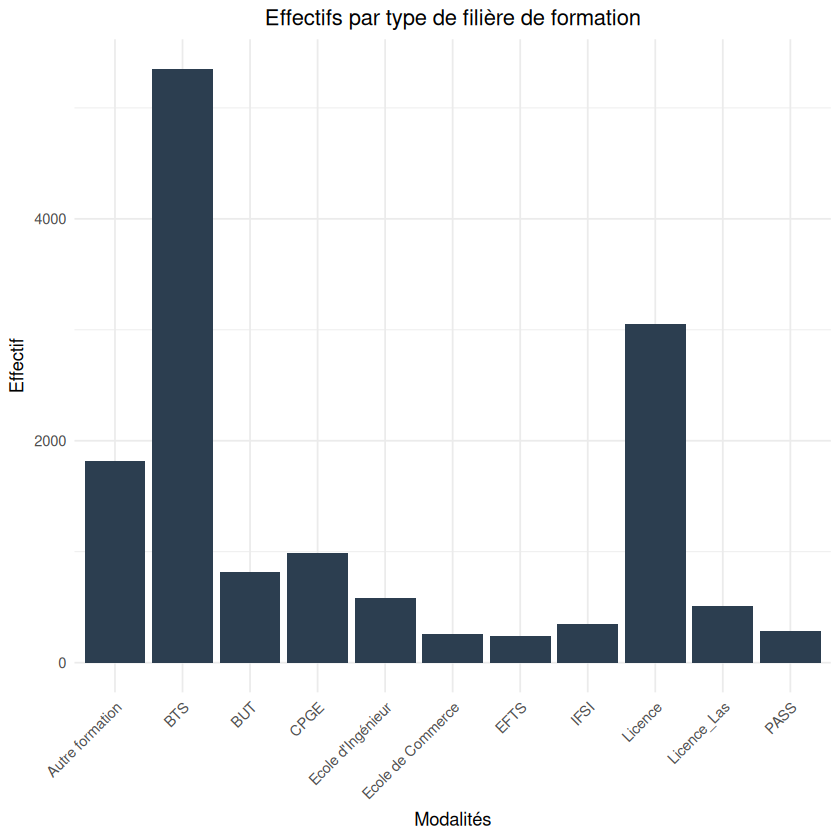

In [70]:
###Effectif par formation
summary(data_features_core$`Filière.de.formation.très.agrégée`)
library(ggplot2)

ggplot(data_features_core, aes(x = `Filière.de.formation.très.agrégée`)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par type de filière de formation",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

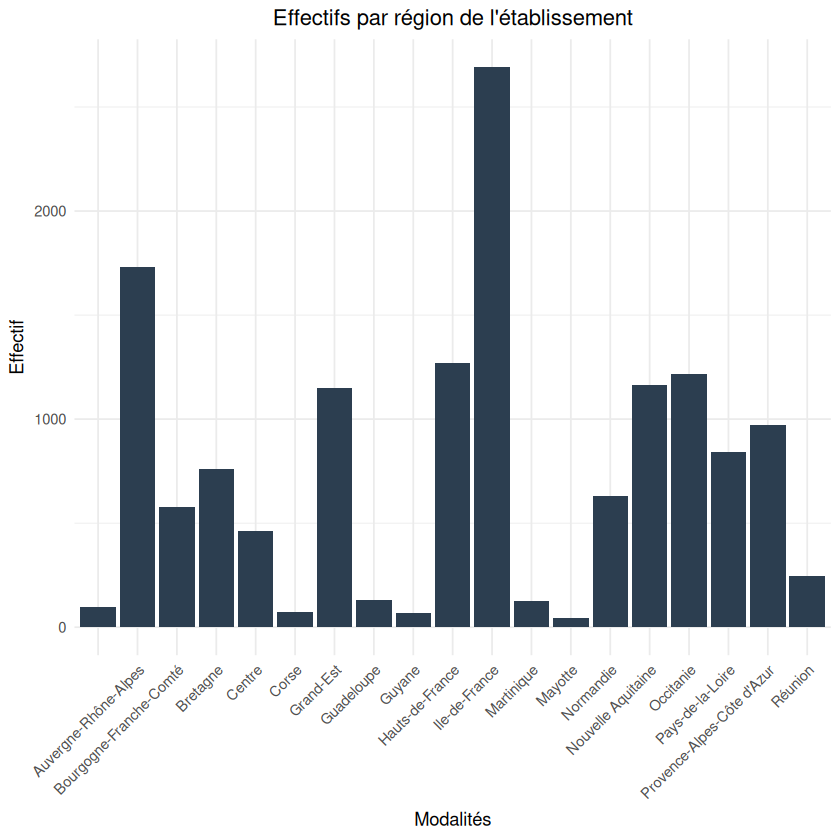

In [71]:
###Effectifs par région
ggplot(data_features_core, aes(x = Région.de.l.établissement)) +
  geom_bar(fill = "#2C3E50") +
  labs(
    title = "Effectifs par région de l'établissement",
    x = "Modalités",
    y = "Effectif"
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(hjust = 0.5),
    axis.text.x = element_text(angle = 45, hjust = 1)
  )

# Analyse pluri-dimensionnelle des variables

In [90]:
library(corrplot)

# Sélectionne les variables numériques pour l'étude
# (On utilise les noms issus du script de nettoyage)
cols_etude <- var_quanti

#Calcule la matrice de corrélation
# On utilise use = "complete.obs" pour ignorer les lignes avec des NA
matrice_corr <- cor(data_features_core%>% select(all_of(cols_etude)), use = "complete.obs")

# Affiche la matrice dans la console
print(round(matrice_corr, 2))
par(mar = c(1, 1, 1, 1))  # réduire les marges

png("corrplot.png", width = 2000, height = 2000, res = 150)
# 4. Visualisation graphique (Heatmap)
corrplot(matrice_corr, 
         method = "color",       
         type = "upper",         
         order = "original",       
         addCoef.col = "black",  
         tl.col = "black",
         tl.cex=0.5,
         number.cex = 0.5,       
         diag = FALSE            
)
dev.off()

                                                                                       Capacité.de.l.établissement.par.formation
Capacité.de.l.établissement.par.formation                                                                                   1.00
Effectif.total.admis.2phases                                                                                                0.78
Effectif.total.candidats.2phases                                                                                            0.42
Pourcentage.boursiers.candidats                                                                                            -0.05
Pourcentage.boursiers.admis                                                                                                -0.03
pct_filles_admises                                                                                                          0.10
pct_garcons_admis                                                                                

agg_record_902946872 
                   2

Remarques: 
Pas un lien important entre mention et pression candidature  
la pression candidature est en revanche liée au taux accès 

In [79]:
###Corrélation : Pression vs Niveau académique (Score Mention)

ggplot(data_features_core, aes(x = log_candidats, y = score_mention)) +
  geom_point(aes(color = Sélectivité), alpha = 0.5) +
  geom_smooth(method = "lm", color = "red") +
  labs(
    title = "Lien entre volume de candidatures et niveau des admis",
    x = "Nombre de candidats (log1p)",
    y = "Score moyen des mentions"
  ) +
  theme_minimal()

ERROR while rich displaying an object: Error in `geom_point()`:
! Problem while computing aesthetics.
ℹ Error occurred in the 1st layer.
Caused by error:
! objet 'log_candidats' introuvable

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(r

Plus il y a de candidats pour une formation plus leurs notes sont élevée en moyenne  (droite de régression rouge)
entre mentions 3 et 4 (bien/très bien) seulement des formations sélectives semblent être demandées

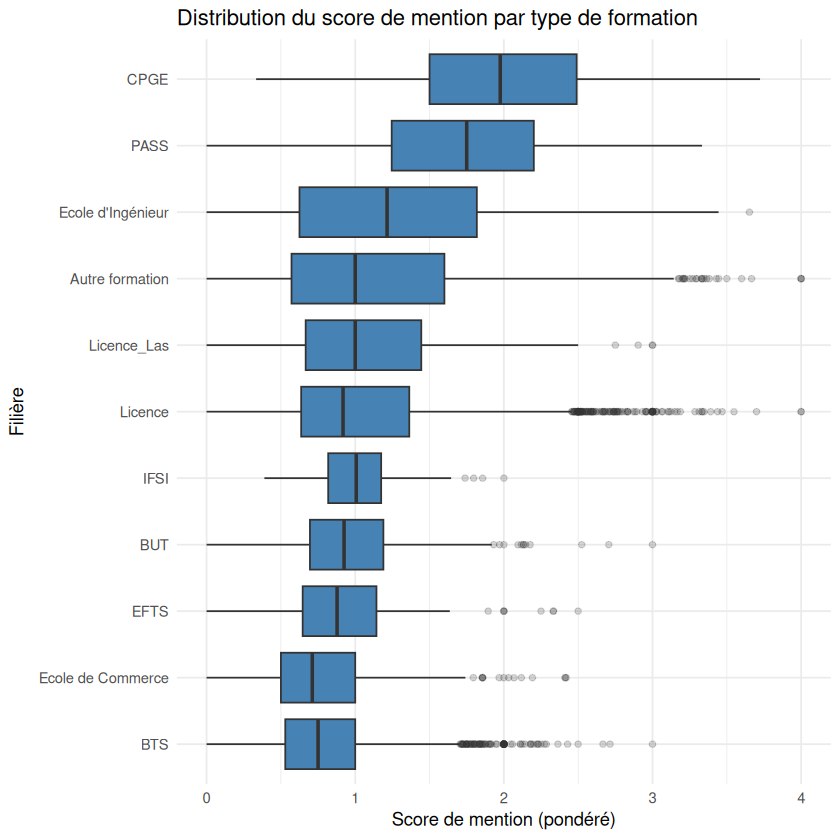

In [80]:
#Niveau admis par fillières
ggplot(data_features_core, aes(x = reorder(Filière.de.formation.très.agrégée, score_mention), y = score_mention)) +
  geom_boxplot(fill = "steelblue", outlier.alpha = 0.2) +
  coord_flip() + # Pour lire les noms des filières horizontalement
  labs(
    title = "Distribution du score de mention par type de formation",
    x = "Filière",
    y = "Score de mention (pondéré)"
  ) +
  theme_minimal()

In [75]:
#Mixité par domaine
data_genre <- data_features_core %>%
  filter(log_admis > 2) # On filtre les petites formations pour la lisibilité

ggplot(data_genre, aes(x = Filière.de.formation.très.agrégée, y = pct_filles_admises)) +
  geom_jitter(alpha = 0.2, color = "purple") + 
  # CORRECTION ICI : yintercept au lieu de y0
  geom_hline(yintercept = 0.5, linetype = "dashed", color = "black") + 
  labs(
    title = "Part des femmes admises par filière",
    subtitle = "La ligne pointillée représente l'équilibre (50%)",
    x = "Filière",
    y = "% de filles parmi les admis"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

ERROR: [1m[33mError[39m in `filter()`:[22m
[1m[22m[36mℹ[39m In argument: `log_admis > 2`.
[1mCaused by error:[22m
[33m![39m objet 'log_admis' introuvable


In [ ]:
dim(data_features_core)

[1] 14252    23

Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
“Ignoring empty aesthetic: `width`.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the factoextra package.
  Please report the issue at <https://github.com/kassambara/factoextra/issues>.”


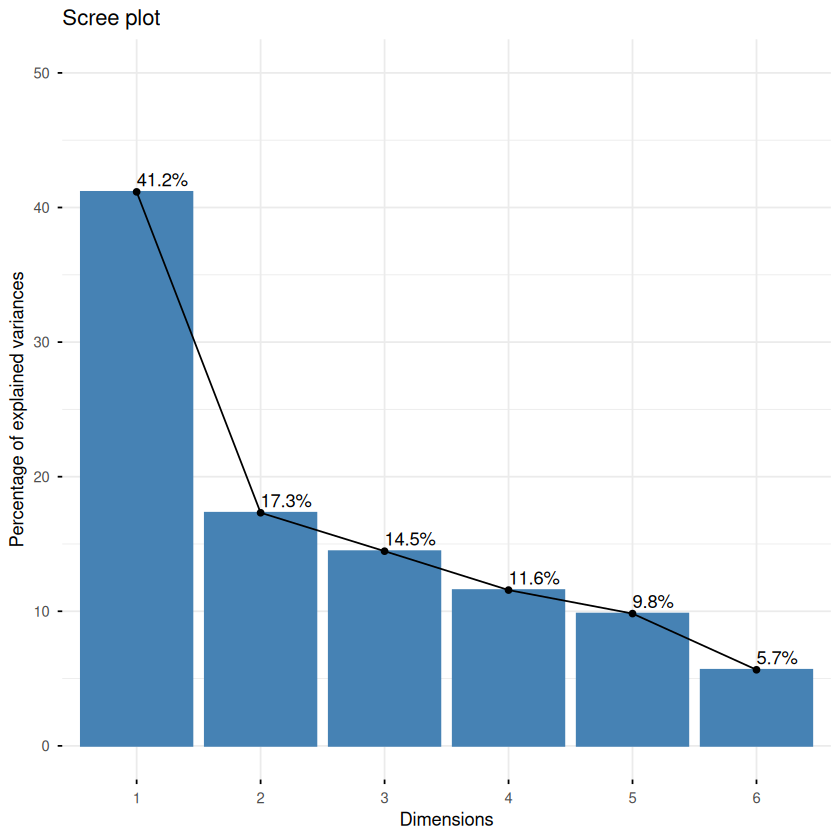

Warning message in PCA(data_pca_full, quali.sup = which(names(data_pca_full) == :
“Missing values are imputed by the mean of the variable: you should use the imputePCA function of the missMDA package”
Warning message in mean.default(X[, j], na.rm = TRUE):
“l'argument n'est ni numérique, ni logique : renvoi de NA”
Warning message in mean.default(X[, j], na.rm = TRUE):
“l'argument n'est ni numérique, ni logique : renvoi de NA”
Warning message in mean.default(X[, j], na.rm = TRUE):
“l'argument n'est ni numérique, ni logique : renvoi de NA”
Warning message in mean.default(X[, j], na.rm = TRUE):
“l'argument n'est ni numérique, ni logique : renvoi de NA”
Warning message in mean.default(X[, j], na.rm = TRUE):
“l'argument n'est ni numérique, ni logique : renvoi de NA”


ERROR: Error in PCA(data_pca_full, quali.sup = which(names(data_pca_full) == : 
The following variables are not quantitative:  Établissement
The following variables are not quantitative:  Filière.de.formation
The following variables are not quantitative:  Filière.de.formation.très.agrégée
The following variables are not quantitative:  Région.de.l.établissement
The following variables are not quantitative:  Académie.de.l.établissement


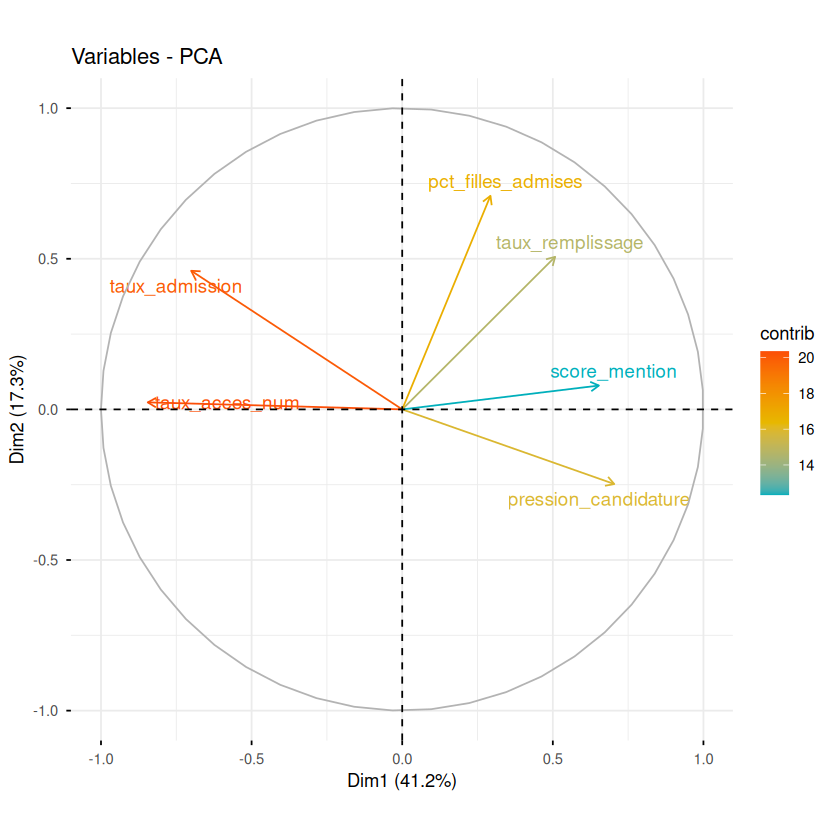

In [ ]:
###ACP
library(FactoMineR)
library(factoextra)
library(tidyr)

# 1. Sélection des variables actives pour l'ACP
# On choisit des ratios plutôt que des volumes bruts pour éviter l'effet de taille
data_pca <- data_features_core %>%
  select(
    pression_candidature,
    taux_admission,
    taux_remplissage,
    taux_acces_num,
    score_mention,
    pct_filles_admises
  ) %>%
  drop_na() # L'ACP nécessite des données complètes

# 2. Exécution de l'ACP
# Les données sont centrées et réduites par défaut (scale.unit = TRUE)
res_pca <- PCA(data_pca, graph = FALSE)

fviz_eig(res_pca, addlabels = TRUE, ylim = c(0, 50))


fviz_pca_var(res_pca, col.var = "contrib", 
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             repel = TRUE)


# On récupère les données sans NA pour pouvoir rattacher la variable qualitative Sélectivité
data_pca_full <- data_features_core %>%
  drop_na(pression_candidature, taux_admission, taux_remplissage, 
          taux_acces_num, score_mention, pct_filles_admises)

# ACP avec la Sélectivité en variable illustrative
res_pca_full <- PCA(data_pca_full, 
                    quali.sup = which(names(data_pca_full) == "Sélectivité"), 
                    graph = FALSE)

fviz_pca_ind(res_pca_full, 
             geom.ind = "point", 
             col.ind = data_pca_full$Sélectivité, 
             palette = "jco",
             addEllipses = TRUE, 
             legend.title = "Sélectivité")

## ACM (Analyse des Correspondances Multiples)

L'ACM est l'équivalent de l'ACP pour les variables qualitatives. Ici, on repart du vecteur `var_quali` créé plus haut pour garder seulement les variables qualitatives, puis on résume les liaisons entre modalités sur quelques axes.

In [ ]:
library(ca)

# On utilise directement le vecteur var_quali créé plus haut
data_mca <- data_features_core %>%
  select(all_of(var_quali)) %>%
  drop_na()

# ACM simple sur les variables qualitatives
res_mca <- mjca(data_mca)

# Résumé rapide des premiers axes
summary(res_mca)

# Carte des modalités sur les deux premiers axes
plot(res_mca)


On commence par regarder le résumé pour voir ce que portent les premiers axes. Puis on lit la carte : deux modalités proches ont tendance à apparaître ensemble, alors que des modalités opposées s'éloignent sur les axes.